# Comparação de Datasets - Precificação de Imóveis

### Objetivo

Este notebook tem como objetivo comparar três datasets de imóveis para selecionar a base de dados mais adequada ao treinamento de um modelo de Machine Learning para precificação de imóveis.

### Contexto do Projeto

Este notebook faz parte do projeto de desenvolvimento de um Sistema de Precificação de Imóveis.

O sistema possui uma API desenvolvida em FastAPI, responsável por receber informações de um imóvel e retornar uma estimativa de preço utilizando um modelo de Machine Learning.

O backend recebe as seguintes informações como entrada:

- Área do imóvel (m²)
- Número de quartos
- Número de banheiros
- Número de vagas de garagem
- Bairro

Assim, o dataset escolhido deve possuir essas informações, ou atributos equivalentes, além da variável alvo correspondente ao preço do imóvel.

### Critérios de Avaliação

Os datasets serão comparados utilizando os seguintes critérios:

1. **Quantidade de registros:** bases maiores tendem a fornecer mais informações para o treinamento do modelo.
2. **Compatibilidade das colunas:** presença das variáveis necessárias para o projeto (área, quartos, banheiros, vagas, bairro e preço).
3. **Granularidade da localização:** verificar se o dataset possui a informação de bairro de forma isolada, ou apenas embutida em um campo de endereço completo (o que exigiria tratamento extra para extrair).
4. **Valores ausentes:** quantidade de dados nulos que podem exigir tratamento.
5. **Registros duplicados:** existência de imóveis repetidos.
6. **Qualidade dos dados:** identificação de valores inconsistentes, como áreas negativas ou preços iguais a zero.
7. **Facilidade de tratamento:** esforço necessário para adaptar o dataset ao formato esperado pelo backend.
8. **Adequação ao modelo:** compatibilidade da base de dados com o treinamento de um modelo de Regressão Linear (ex: presença de outliers extremos, relações não-lineares entre variáveis e preço).

Ao final da comparação, será escolhido o dataset que apresentar melhor equilíbrio entre qualidade, completude e compatibilidade com os requisitos do projeto.

### Preparação do Ambiente

##### Importação das bibliotecas

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

##### Carregamento dos datasets

In [3]:
dataset_a = pd.read_csv("../dados/dataset_A.csv", encoding="utf-8", encoding_errors="replace")
dataset_b = pd.read_csv("../dados/dataset_B.csv")
dataset_c = pd.read_csv("../dados/dataset_C.csv")

**Nota:** dataset_A.csv precisou de `encoding="latin-1"` para carregar corretamente (possui caracteres acentuados fora do padrão UTF-8).

In [ ]:
dataset_a[dataset_a.apply(lambda row: row.astype(str).str.contains("�").any(), axis=1)]

## Dataset A

### Visão geral

Quantidade de linhas e de colunas (linhas, colunas):

In [5]:
print("Shape:", dataset_a.shape)

Shape: (133964, 18)


Exibição das primeiras 10 linhas:

In [6]:
dataset_a.head(10)

,logradouro,numero,bairro,cep,cidade,tipo_imovel,area_util,banheiros,suites,quartos,vagas_garagem,anuncio_criado,tipo_anuncio,preco_venda,taxa_condominio,periodicidade,preco_aluguel,iptu_ano
0,Rua Juvenal Galeno,53,Jardim da Saúde,4290030.0,São Paulo,Casa de dois andares,388.0,3.0,1.0,4.0,6.0,2017-02-07,Venda,700000,NaN,NaN,NaN,NaN
1,Rua Juruaba,16,Vila Santa Teresa (Zona Sul),4187320.0,São Paulo,Casa,129.0,2.0,1.0,3.0,2.0,2016-03-21,Venda,336000,NaN,NaN,NaN,NaN
2,Avenida Paulista,402,Bela Vista,1311000.0,São Paulo,Comercial,396.0,4.0,0.0,0.0,5.0,2018-12-18,Locação,24929,4900.0,MONTHLY,29829.0,4040.0
3,Rua Alvorada,1190,Vila Olímpia,4550004.0,São Paulo,Apartamento,80.0,2.0,1.0,3.0,2.0,2018-10-26,Venda,739643,686.0,NaN,NaN,1610.0
4,Rua Curitiba,380,Paraíso,4005030.0,São Paulo,Apartamento,3322.0,5.0,4.0,4.0,5.0,2018-12-14,Venda,7520099,6230.0,NaN,NaN,18900.0
5,Rua Pintassilgo,477,Vila Uberabinha,4514032.0,São Paulo,Flat,45.0,0.0,1.0,1.0,1.0,2018-10-09,Locação,1889,560.0,MONTHLY,2450.0,87.0
6,Rua Mateus Grou,586,Pinheiros,5415040.0,São Paulo,Apartamento,94.0,1.0,0.0,3.0,2.0,2018-05-29,Venda,630700,1120.0,NaN,NaN,489.0
7,Rua Dona Luísa de Paiva Dias,NaN,Vila Santa Clara,3274050.0,São Paulo,Condomínio,110.0,1.0,1.0,3.0,2.0,2018-04-16,Venda,385000,0.0,NaN,NaN,0.0
8,Rua Oswaldo Arouca,213,Vila Formosa,3363000.0,São Paulo,Depósito,590.0,2.0,0.0,0.0,20.0,2018-06-26,Venda,1400000,0.0,NaN,NaN,5600.0
9,Rua Almeida Torres,140,Aclimação,1530010.0,São Paulo,Apartamento,141.0,4.0,3.0,4.0,2.0,2019-01-09,Venda,1106000,0.0,NaN,NaN,0.0


***Comentários***: Apesar do dataset ter a quantidade mínima viável de itens (>5k), nem todas são referentes à vendas de casa, conforme pode ser observado nos dados da coluna `tipo_imovel` e da coluna `tipo_anuncio`. Por isso, foi realizada uma verificação das categorias de dados das colunas, para posterior filtro utilizando a categoria que contemple o escopo do projeto.<br>
<br>


---

#### Filtragem de dados

**FILTRO POR TIPO DE IMÓVEL**

Listagem de itens da coluna `tipo_imovel`:

In [7]:
dataset_a['tipo_imovel'].unique()

<StringArray>
[  'Casa de dois andares',                   'Casa',              'Comercial',
            'Apartamento',                   'Flat',             'Condomínio',
               'Depósito', 'Loteamento Residencial',              'Cobertura',
                   'Loja',     'Prédio Residencial',             'Escritório',
   'Loteamento Comercial',                 'Kitnet',       'Prédio Comercial',
                'Clínica',          'Casa de Campo',                'Fazenda']
Length: 18, dtype: str

Contagem de itens, por categoria, da coluna `tipo_imovel`

In [8]:
dataset_a['tipo_imovel'].value_counts()

tipo_imovel
Apartamento               72241
Casa de dois andares      18068
Casa                       9030
Escritório                 7714
Flat                       7661
Comercial                  6534
Condomínio                 4015
Cobertura                  2772
Depósito                   2197
Loteamento Residencial     1430
Loteamento Comercial        807
Loja                        694
Kitnet                      522
Prédio Residencial          142
Prédio Comercial             85
Clínica                      33
Fazenda                      10
Casa de Campo                 9
Name: count, dtype: int64

***Comentários***: valores contendo "Casa" ("Casa", "Casa de dois andares" e "Casa de Campo") serão utilizados na análise filtrada. Os demais serão desconsiderados, por estarem fora do escopo do projeto.

Atribuição da variável específica para 'Casas' no dataset:

In [9]:
dataset_a_casas = dataset_a[dataset_a['tipo_imovel'].str.contains("Casa", case=False, na=False)]

**FILTRO POR TIPO DE ANÚNCIO**

Listagem de itens da coluna `tipo_anuncio`

In [10]:
dataset_a['tipo_anuncio'].unique()

<StringArray>
['Venda', 'Locação']
Length: 2, dtype: str

Contagem de itens, por categoria, da coluna `tipo_anuncio`

In [11]:
dataset_a['tipo_anuncio'].value_counts()

tipo_anuncio
Venda      105332
Locação     28632
Name: count, dtype: int64

***Comentários***: valores contendo "Venda" serão utilizados na análise filtrada. Os demais serão desconsiderados, por estarem fora do escopo do projeto.

Atribuição da variável específica para 'Vendas', aplicada em cima do filtro de 'Casas' no dataset:

In [52]:
dataset_a_casas_venda = dataset_a_casas[dataset_a_casas['tipo_anuncio'].str.contains("Venda", case=False, na=False)]

---

#### Visão geral (com filtros)

**Filtros aplicados ao Dataset A:**
- `tipo_imovel` contendo "Casa" (inclui variações como "Casa de dois andares")
- `tipo_anuncio` contendo "Venda" (excluindo "Locação")

Quantidade de linhas e de colunas com o filtro aplicado:

In [13]:
print("Shape:", dataset_a_casas_venda.shape)
print("Total de linhas antes do filtro:", dataset_a.shape[0])
print("Total de linhas depois do filtro:", dataset_a_casas_venda.shape[0])

Shape: (24961, 18)
Total de linhas antes do filtro: 133964
Total de linhas depois do filtro: 24961


Exibição das 10 primeiras linhas com o filtro aplicado:

In [14]:
dataset_a_casas_venda.head(10)

,logradouro,numero,bairro,cep,cidade,tipo_imovel,area_util,banheiros,suites,quartos,vagas_garagem,anuncio_criado,tipo_anuncio,preco_venda,taxa_condominio,periodicidade,preco_aluguel,iptu_ano
0,Rua Juvenal Galeno,53,Jardim da Saúde,4290030.0,São Paulo,Casa de dois andares,388.0,3.0,1.0,4.0,6.0,2017-02-07,Venda,700000,NaN,NaN,NaN,NaN
1,Rua Juruaba,16,Vila Santa Teresa (Zona Sul),4187320.0,São Paulo,Casa,129.0,2.0,1.0,3.0,2.0,2016-03-21,Venda,336000,NaN,NaN,NaN,NaN
19,Rua Sant'Ana,00,Campo Grande,4676110.0,São Paulo,Casa de dois andares,99.0,4.0,3.0,3.0,4.0,2018-12-05,Venda,315000,0.0,NaN,NaN,0.0
26,Rua Hermógenes Lima,50,Jardim Monte Azul,5836230.0,São Paulo,Casa de dois andares,140.0,3.0,1.0,3.0,4.0,2018-10-25,Venda,385000,0.0,NaN,NaN,0.0
29,Rua do Erário,12,Móoca,3188070.0,São Paulo,Casa de dois andares,200.0,2.0,0.0,4.0,4.0,2018-07-25,Venda,482999,0.0,NaN,NaN,0.0
37,Rua Macajuba,345,Jardim Iracema,5847540.0,São Paulo,Casa,80.0,1.0,0.0,2.0,2.0,2018-10-30,Venda,258999,0.0,NaN,NaN,0.0
47,Rua Emboabas,10,Brooklin,4623010.0,São Paulo,Casa,175.0,4.0,1.0,3.0,2.0,2018-12-04,Venda,1260000,0.0,NaN,NaN,305.0
65,Rua Antônio Ferraciolli,NaN,Jardim Catarina,3910070.0,São Paulo,Casa de dois andares,147.0,2.0,1.0,3.0,2.0,2017-04-26,Venda,385000,0.0,NaN,NaN,0.0
75,Rua Refinaria Presidente Bernardes,NaN,Vila Antonieta,3475000.0,São Paulo,Casa de dois andares,181.0,2.0,0.0,3.0,2.0,2017-04-27,Venda,280000,0.0,NaN,NaN,0.0
77,Avenida Interlagos,4455,Jardim Umuarama,4661300.0,São Paulo,Casa,110.0,2.0,1.0,3.0,2.0,2017-10-28,Venda,535500,532.0,NaN,NaN,0.0


---

### Tipos das colunas

Listagem de colunas e tipos:

In [15]:
dataset_a.dtypes

logradouro             str
numero                 str
bairro                 str
cep                float64
cidade                 str
tipo_imovel            str
area_util          float64
banheiros          float64
suites             float64
quartos            float64
vagas_garagem      float64
anuncio_criado         str
tipo_anuncio           str
preco_venda          int64
taxa_condominio    float64
periodicidade          str
preco_aluguel      float64
iptu_ano           float64
dtype: object

Tabela comparativa:

| Variável projeto | Coluna equivalente no Dataset |
|---|---|
| area_m2 | area_util |
| quartos | quartos |
| banheiros | banheiros |
| vagas | vagas_garagem |
| bairro | bairro |
| preco | preco_venda |


***Comentários***: Possui todas as variáveis ewquivalentes.

---

### Valores nulos

Quantidade total de valores nulos em cada coluna:

In [16]:
dataset_a.isnull().sum()

logradouro           7002
numero              44141
bairro                 21
cep                  5908
cidade                  0
tipo_imovel             0
area_util            3096
banheiros             913
suites              13617
quartos              3019
vagas_garagem        4425
anuncio_criado          0
tipo_anuncio            0
preco_venda             0
taxa_condominio     16837
periodicidade      104913
preco_aluguel      105250
iptu_ano            19352
dtype: int64

#### Valores nulos (com filtros)

Quantidade total de valores nulos em cada coluna, com os filtros aplicados:

In [17]:
dataset_a_casas_venda.isnull().sum()

logradouro          1832
numero              9322
bairro                 1
cep                 1338
cidade                 0
tipo_imovel            0
area_util           1248
banheiros              3
suites              1923
quartos                3
vagas_garagem        446
anuncio_criado         0
tipo_anuncio           0
preco_venda            0
taxa_condominio     7708
periodicidade      24922
preco_aluguel      24954
iptu_ano            5477
dtype: int64

---

### Valores duplicados

Quantidade total de linhas duplicadas:

Obs.: às vezes duplicatas não são idênticas linha a linha, mas repetem o mesmo imóvel com pequenas variações

In [18]:
print("Linhas duplicadas:", dataset_a.duplicated().sum())

Linhas duplicadas: 1271


#### Valores duplicados (com filtros)

Quantidade total de linhas duplicadas, com filtros aplicados:

Obs.: às vezes duplicatas não são idênticas linha a linha, mas repetem o mesmo imóvel com pequenas variações

In [19]:
print("Linhas duplicadas:", dataset_a_casas_venda.duplicated().sum())

Linhas duplicadas: 81


---

### Estatísticas descritivas

- Quantidade de valores não vazios
- Média aritmérica
- Desio padrão
- Valor mínimo
- Valor máximo
- Percentuais

count - The number of not-empty values. <br>
mean - The average (mean) value. <br>
std - The standard deviation.<br>
min - the minimum value.<br>
25% - The 25% percentile*.<br>
50% - The 50% percentile*.<br>
75% - The 75% percentile*.<br>
max - the maximum value.<br>

*Percentile meaning: how many of the values are less than the given percentile. 

In [20]:
dataset_a.describe()

,cep,area_util,banheiros,suites,quartos,vagas_garagem,preco_venda,taxa_condominio,preco_aluguel,iptu_ano
count,1.280560e+05,1.308680e+05,133051.000000,120347.000000,130945.000000,129539.000000,1.339640e+05,1.171270e+05,2.871400e+04,1.146120e+05
mean,3.550899e+06,2.244307e+02,2.375683,1.106534,2.327023,2.443187,6.637484e+05,1.507679e+03,1.102183e+04,4.182520e+03
std,2.177019e+06,5.764345e+03,2.146044,1.218938,2.140123,5.251624,1.317732e+06,7.795406e+04,7.701223e+04,8.501091e+05
min,0.000000e+00,1.000000e+00,0.000000,0.000000,0.000000,0.000000,7.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.312135e+06,6.200000e+01,1.000000,0.000000,2.000000,1.000000,1.750000e+05,0.000000e+00,2.310000e+03,0.000000e+00
50%,3.413030e+06,1.080000e+02,2.000000,1.000000,2.000000,2.000000,3.710000e+05,3.990000e+02,4.111500e+03,8.400000e+01
75%,4.576050e+06,2.000000e+02,3.000000,2.000000,3.000000,3.000000,7.000000e+05,8.610000e+02,9.100000e+03,3.640000e+02
max,9.981030e+07,2.025000e+06,200.000000,80.000000,600.000000,589.000000,8.400000e+07,2.443000e+07,1.190000e+07,2.830242e+08


#### Estatísicas descritivas (com filtros)

Mesmas estatísticas, mas com os filtros aplicados:

In [21]:
dataset_a_casas_venda.describe()

,cep,area_util,banheiros,suites,quartos,vagas_garagem,preco_venda,taxa_condominio,preco_aluguel,iptu_ano
count,2.362300e+04,23713.000000,24958.000000,23038.000000,24958.000000,24515.000000,2.496100e+04,17253.000000,7.0,1.948400e+04
mean,3.594479e+06,218.836250,2.836565,1.362184,2.991866,3.040139,7.713275e+05,68.734655,0.0,8.711314e+02
std,1.698195e+06,394.080844,1.683475,1.311790,1.001328,2.240884,9.907414e+05,3885.182048,0.0,2.114073e+04
min,0.000000e+00,1.000000,0.000000,0.000000,0.000000,0.000000,5.949900e+04,0.000000,0.0,0.000000e+00
25%,2.375085e+06,120.000000,2.000000,1.000000,2.000000,2.000000,3.500000e+05,0.000000,0.0,0.000000e+00
50%,3.274010e+06,165.000000,3.000000,1.000000,3.000000,2.000000,4.899990e+05,0.000000,0.0,0.000000e+00
75%,4.632010e+06,250.000000,4.000000,2.000000,3.000000,4.000000,7.700000e+05,0.000000,0.0,2.100000e+02
max,8.592680e+07,32773.000000,33.000000,80.000000,40.000000,99.000000,3.500000e+07,445200.000000,0.0,1.750000e+06


---

### Histograma


- Histograma do preço

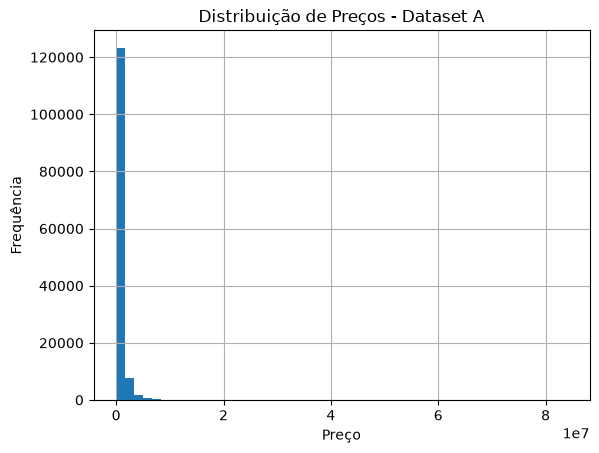

In [22]:
dataset_a['preco_venda'].hist(bins=50)
plt.title("Distribuição de Preços - Dataset A")
plt.xlabel("Preço")
plt.ylabel("Frequência")
plt.show()

#### Histograma (com filtros)

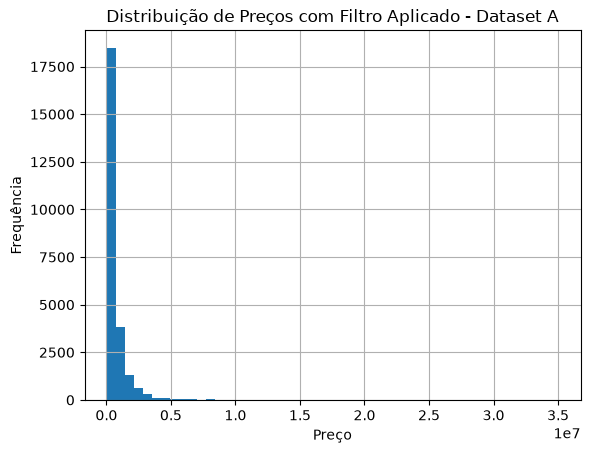

In [42]:
dataset_a_casas_venda['preco_venda'].hist(bins=50)
plt.title("Distribuição de Preços com Filtro Aplicado - Dataset A")
plt.xlabel("Preço")
plt.ylabel("Frequência")
plt.show()

Verificação de valores extremos:

In [43]:
print("Área > 1000 m²:", (dataset_a_casas_venda['area_util'] > 1000).sum())
print("Quartos > 10:", (dataset_a_casas_venda['quartos'] > 10).sum())
print("Vagas > 10:", (dataset_a_casas_venda['vagas_garagem'] > 10).sum())
print("Banheiros > 10:", (dataset_a_casas_venda['banheiros'] > 10).sum())
print("CEP == 0:", (dataset_a_casas_venda['cep'] == 0).sum())

Área > 1000 m²: 80
Quartos > 10: 15
Vagas > 10: 154
Banheiros > 10: 25
CEP == 0: 144


## Dataset B

### Visão geral

Quantidade de linhas e de colunas (linhas, colunas):

In [25]:
print("Shape:", dataset_b.shape)

Shape: (1085, 7)


Exibição das primeiras 10 linhas:

In [26]:
dataset_b.head(10)

,nome_casa,endereço_casa,preco_casa,metros_casa,quartos_casa,banheiros_casa,vagas_casa
0,"Casa com 4 Quartos à Venda, 360m²","Rua Fortaleza, 342 - Jardim Panorama, Salto - SP",R$ 760.000,360,4,5,2
1,"Casa com 3 Quartos à Venda, 219m²","Rua das Palmas - Residencial Porto Seguro, Sal...",R$ 475.000,219,3,2,2
2,"Casa com 3 Quartos à Venda, 180m²","Rua Escócia - Jardim Elizabeth, Salto - SP",R$ 700.000,180,3,2,2
3,"Casa com 4 Quartos à Venda, 300m²","Rua dos Curumbatás - Urb Salto de São José, Sa...",R$ 1.562.000,300,4,3,4
4,"Casa com 3 Quartos à Venda, 308m²","Rua dos Pássaros, 0 - Residencial Lagos D Icar...",R$ 913.000,308,3,4,2
5,"Casa com 3 Quartos à Venda, 164m²","Rua Ramon Garcia, 137 - Village Moutonnee, Sal...",R$ 550.000,164,3,3,4
6,"Casa com 2 Quartos à Venda, 100m²","Rua Juquei, 11 - Jardim D'icarai, Salto - SP",R$ 435.000,100,2,2,2
7,"Casa com 3 Quartos à Venda, 199m²","Rua dos Pássaros, 0 - Residencial Lagos D Icar...",R$ 950.000,199,3,3,2
8,"Casa com 3 Quartos à Venda, 124m²","Rua Antônio João Dias, 22 - CONDOMINIO ZULEIKA...",R$ 6.000 /mês,124,3,3,4
9,Casa com 3 Quartos à Venda/Aluguel 290m²,"CONDOMINIO ZULEIKA JABOUR, Salto - SP",R$ 1.100.000,290,3,4,2


**Nota:** segundo a descrição do dataset no Kaggle, os dados referem-se exclusivamente a casas à venda — não há necessidade de filtro por tipo_imovel/tipo_anuncio.

### Tipos das colunas

Listagem de colunas e tipos:

In [27]:
dataset_b.dtypes

nome_casa           str
endereço_casa       str
preco_casa          str
metros_casa       int64
quartos_casa      int64
banheiros_casa    int64
vagas_casa        int64
dtype: object

Tabela comparativa:

| Variável projeto | Coluna equivalente no Dataset |
|---|---|
| area_m2 | metros_casa |
| quartos | quartos_casa |
| banheiros | banheiros_casa |
| vagas | vagas_casa |
| bairro | endereço_casa |
| preco | preco_casa |


***Comentários***: Os dados do bairro estão contidos dentro da coluna de endereço, precisarão ser extraídos da coluna.

### Valores nulos

Quantidade total de valores nulos em cada coluna:

In [28]:
dataset_b.isnull().sum()

nome_casa         0
endereço_casa     0
preco_casa        0
metros_casa       0
quartos_casa      0
banheiros_casa    0
vagas_casa        0
dtype: int64

### Valores duplicados

Quantidade total de linhas duplicadas:

Obs.: às vezes duplicatas não são idênticas linha a linha, mas repetem o mesmo imóvel com pequenas variações

In [29]:
print("Linhas duplicadas:", dataset_b.duplicated().sum())

Linhas duplicadas: 1


### Estatísticas descritivas

- Quantidade de valores não vazios
- Média aritmérica
- Desio padrão
- Valor mínimo
- Valor máximo
- Percentuais

count - The number of not-empty values. <br>
mean - The average (mean) value. <br>
std - The standard deviation.<br>
min - the minimum value.<br>
25% - The 25% percentile*.<br>
50% - The 50% percentile*.<br>
75% - The 75% percentile*.<br>
max - the maximum value.<br>

*Percentile meaning: how many of the values are less than the given percentile. 

In [30]:
dataset_b.describe()

,metros_casa,quartos_casa,banheiros_casa,vagas_casa
count,1085.000000,1085.000000,1085.000000,1085.000000
mean,185.213825,2.891244,2.669124,2.886636
std,98.584261,0.773862,1.291548,2.691221
min,35.000000,1.000000,1.000000,1.000000
25%,110.000000,2.000000,2.000000,2.000000
50%,164.000000,3.000000,2.000000,2.000000
75%,290.000000,3.000000,3.000000,3.000000
max,395.000000,5.000000,6.000000,18.000000


### Histograma

- Histograma do preço

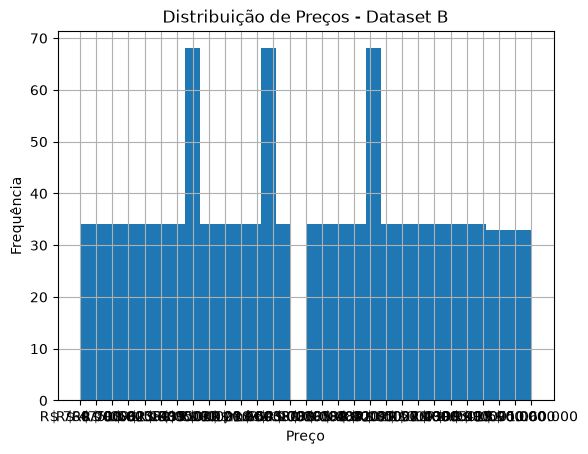

In [41]:
dataset_b['preco_casa'].hist(bins=30)
plt.title("Distribuição de Preços - Dataset B")
plt.xlabel("Preço")
plt.ylabel("Frequência")
plt.show()

**Comentários**: Os dados de `preco_casa` estão em string, necessário converter para float.

## Dataset C

### Visão geral

Quantidade de linhas e de colunas (linhas, colunas):

In [32]:
print("Shape:", dataset_c.shape)

Shape: (924, 22)


Exibição das primeiras 10 linhas:

In [33]:
dataset_c.head(10)

,valor,classe,dormitorios,banheiros,vagas_na_garagem,tipo_do_imovel,bairro,area_terreno,area_util,condominio,...,elevador_social,suites,apartamento_por_andar,quantidade_de_andares,elevador_de_servico,salao_de_festa,iptu,lat,long,dist_centro
0,280000.0,Casa,2.0,1.0,2.0,Padrão,jardim sao bento,206.0,134.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-21.834613,-46.572337,5.179980
1,350000.0,Apartamento,2.0,1.0,NaN,Padrão,centro,NaN,71.0,55.0,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,-21.788380,-46.566182,0.000000
2,3000000.0,Terreno,NaN,NaN,NaN,Padrão,jardim campos elisios,3200.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,450000.0,Apartamento,2.0,2.0,2.0,Padrão,jardim dos estados,NaN,72.0,230.0,...,1.0,1.0,7.0,4.0,1.0,NaN,NaN,-21.782685,-46.559694,0.921824
4,1350000.0,Casa,5.0,4.0,6.0,Padrão,sao benedito,297.0,483.0,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,-21.855860,-46.571666,7.524761
5,60000.0,Terreno,NaN,NaN,NaN,Loteamento,morada dos passaros,300.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,150000.0,Comercial,NaN,1.0,NaN,Ponto comercial,centro,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-21.788380,-46.566182,0.000000
7,650000.0,Casa,3.0,3.0,3.0,Padrão,jardim das hortencias,125.0,138.0,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,320000.0,Apartamento,2.0,1.0,1.0,Padrão,centro,NaN,NaN,260.0,...,1.0,NaN,4.0,11.0,NaN,NaN,NaN,-21.788380,-46.566182,0.000000
9,425000.0,Casa,3.0,2.0,1.0,Padrão,jardim vitoria,180.0,109.0,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


***Comentários***: Nem todas as linhas são referentes à vendas de casa, conforme pode ser observado nos dados da coluna `classe` e da coluna `tipo_imovel`. Por isso, foi realizada uma verificação das categorias de dados das colunas, para posterior filtro utilizando a categoria que contemple o escopo do projeto.<br>
<br>


---

#### Filtragem de dados

**FILTRO POR CLASSE**

Listagem de itens da coluna `classe`:

In [44]:
dataset_c['classe'].unique()

<StringArray>
['Casa', 'Apartamento', 'Terreno', 'Comercial', 'Rurais']
Length: 5, dtype: str

Contagem de itens, por categoria, da coluna `classe`:

In [45]:
dataset_c['classe'].value_counts()

classe
Apartamento    432
Casa           334
Terreno        119
Comercial       33
Rurais           6
Name: count, dtype: int64

***Comentários***: valores contendo "Casa" serão utilizados na análise filtrada. Os demais serão desconsiderados, por estarem fora do escopo do projeto.


Atribuição da variável específica para 'Casas' no dataset:


In [46]:
dataset_c_casas = dataset_c[dataset_c['classe'].str.contains("Casa", case=False, na=False)]

**FILTRO POR TIPO DE IMÓVEL**

Listagem de itens da coluna `tipo_do_imovel`, já com filtro de Casa aplicado:


In [50]:
dataset_c_casas['tipo_do_imovel'].unique()

<StringArray>
['Padrão', 'Casa em condomínio', 'Condomínio de Chácara']
Length: 3, dtype: str

Contagem de itens, por categoria, da coluna `tipo_do_imovel`

In [51]:
dataset_c_casas['tipo_do_imovel'].value_counts()

tipo_do_imovel
Padrão                   314
Casa em condomínio        19
Condomínio de Chácara      1
Name: count, dtype: int64

***Comentários***: valores contendo "Padrão" serão utilizados na análise filtrada. Os demais serão desconsiderados, por estarem fora do escopo do projeto.

Atribuição da variável específica para 'Padrão', aplicada em cima do filtro de 'Casas' no dataset:

In [53]:
dataset_c_casas_padrao = dataset_c_casas[dataset_c_casas['tipo_do_imovel'].str.contains("Padrão", case=False, na=False)]

#### Visão geral (com filtros)

**Filtros aplicados ao Dataset C:**
- `classe` contendo "Casa"
- `tipo_do_imovel` contendo "Padrão" (excluindo "Condomínio" e afins)

Quantidade de linhas e de colunas com o filtro aplicado:

In [63]:
print("Shape:", dataset_c_casas_padrao.shape)
print("Total de linhas antes do filtro:", dataset_c.shape[0])
print("Total de linhas depois do filtro:", dataset_c_casas_padrao.shape[0])

Shape: (314, 22)
Total de linhas antes do filtro: 924
Total de linhas depois do filtro: 314


Exibição das 10 primeiras linhas com o filtro aplicado:

In [64]:
dataset_c_casas_padrao.head(10)

,valor,classe,dormitorios,banheiros,vagas_na_garagem,tipo_do_imovel,bairro,area_terreno,area_util,condominio,...,elevador_social,suites,apartamento_por_andar,quantidade_de_andares,elevador_de_servico,salao_de_festa,iptu,lat,long,dist_centro
0,280000.0,Casa,2.0,1.0,2.0,Padrão,jardim sao bento,206.0,134.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-21.834613,-46.572337,5.179980
4,1350000.0,Casa,5.0,4.0,6.0,Padrão,sao benedito,297.0,483.0,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,-21.855860,-46.571666,7.524761
7,650000.0,Casa,3.0,3.0,3.0,Padrão,jardim das hortencias,125.0,138.0,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,425000.0,Casa,3.0,2.0,1.0,Padrão,jardim vitoria,180.0,109.0,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,350000.0,Casa,2.0,2.0,1.0,Padrão,jardim centenario,250.0,113.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-21.805588,-46.565064,1.916985
14,319000.0,Casa,2.0,2.0,2.0,Padrão,jardim sao bento,180.0,117.0,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,-21.834613,-46.572337,5.179980
21,450000.0,Casa,3.0,2.0,2.0,Padrão,jardim country club,198.0,104.0,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,-21.789451,-46.589775,2.438972
26,280000.0,Casa,2.0,2.0,2.0,Padrão,santa teresa,125.0,70.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-21.791382,-46.540401,2.682746
27,300000.0,Casa,2.0,2.0,2.0,Padrão,jardim sao bento,180.0,110.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-21.834613,-46.572337,5.179980
29,450000.0,Casa,2.0,2.0,4.0,Padrão,residencial santa clara,160.0,144.0,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,-21.788288,-46.551419,1.524344


### Tipos das colunas

Listagem de colunas e tipos:

In [34]:
dataset_c.dtypes

valor                    float64
classe                       str
dormitorios              float64
banheiros                float64
vagas_na_garagem         float64
tipo_do_imovel               str
bairro                       str
area_terreno             float64
area_util                float64
condominio               float64
torres                   float64
portaria_hrs             float64
elevador_social          float64
suites                   float64
apartamento_por_andar    float64
quantidade_de_andares    float64
elevador_de_servico      float64
salao_de_festa           float64
iptu                     float64
lat                      float64
long                     float64
dist_centro              float64
dtype: object

Tabela comparativa:

| Variável projeto | Coluna equivalente no Dataset |
|---|---|
| area_m2 | area_util / area_terreno |
| quartos | dormitorios |
| banheiros | banheiros |
| vagas | vagas_na_garagem |
| bairro | bairro |
| preco | valor |


***Comentários***: Há área do terreno e área útil.

### Valores nulos

Quantidade total de valores nulos em cada coluna:

In [35]:
dataset_c.isnull().sum()

valor                      0
classe                     0
dormitorios              150
banheiros                125
vagas_na_garagem         184
tipo_do_imovel             0
bairro                     0
area_terreno             464
area_util                494
condominio               486
torres                   623
portaria_hrs             790
elevador_social          694
suites                   404
apartamento_por_andar    571
quantidade_de_andares    566
elevador_de_servico      789
salao_de_festa           807
iptu                     752
lat                      324
long                     324
dist_centro              324
dtype: int64

#### Valores nulos (com filtros)

Quantidade total de valores nulos em cada coluna, com os filtros aplicados:

In [55]:
dataset_c_casas_padrao.isnull().sum()

valor                      0
classe                     0
dormitorios                0
banheiros                  0
vagas_na_garagem          16
tipo_do_imovel             0
bairro                     0
area_terreno              41
area_util                247
condominio               311
torres                   314
portaria_hrs             314
elevador_social          314
suites                   100
apartamento_por_andar    314
quantidade_de_andares    314
elevador_de_servico      314
salao_de_festa           314
iptu                     270
lat                      117
long                     117
dist_centro              117
dtype: int64

### Valores duplicados

Quantidade total de linhas duplicadas:

Obs.: às vezes duplicatas não são idênticas linha a linha, mas repetem o mesmo imóvel com pequenas variações

In [36]:
print("Linhas duplicadas:", dataset_c.duplicated().sum())

Linhas duplicadas: 17


#### Valores duplicados (com filtros)

Quantidade total de linhas duplicadas, com filtros aplicados:

Obs.: às vezes duplicatas não são idênticas linha a linha, mas repetem o mesmo imóvel com pequenas variações

In [57]:
print("Linhas duplicadas:", dataset_c_casas_padrao.duplicated().sum())

Linhas duplicadas: 3


### Estatísticas descritivas

- Quantidade de valores não vazios
- Média aritmérica
- Desio padrão
- Valor mínimo
- Valor máximo
- Percentuais

count - The number of not-empty values. <br>
mean - The average (mean) value. <br>
std - The standard deviation.<br>
min - the minimum value.<br>
25% - The 25% percentile*.<br>
50% - The 50% percentile*.<br>
75% - The 75% percentile*.<br>
max - the maximum value.<br>

*Percentile meaning: how many of the values are less than the given percentile. 

In [37]:
dataset_c.describe()

,valor,dormitorios,banheiros,vagas_na_garagem,area_terreno,area_util,condominio,torres,portaria_hrs,elevador_social,suites,apartamento_por_andar,quantidade_de_andares,elevador_de_servico,salao_de_festa,iptu,lat,long,dist_centro
count,9.240000e+02,774.000000,799.000000,740.000000,460.000000,430.000000,438.000000,301.000000,134.000000,230.000000,520.000000,353.000000,358.000000,135.000000,117.0,172.000000,600.000000,600.000000,600.000000
mean,5.744911e+05,2.686047,2.023780,2.037838,1285.140304,179.077651,2469.914315,2.089701,20.007463,1.178261,1.332692,3.934844,6.611732,1.044444,0.0,175.934012,-21.798190,-46.566503,2.468926
std,5.486207e+05,0.900416,1.204913,1.398308,8343.071182,1157.836651,45379.352934,3.095469,6.459237,0.589913,0.725856,4.345681,4.256822,0.206848,0.0,678.629161,0.021928,0.023237,2.605554
min,5.600000e+04,1.000000,1.000000,1.000000,10.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,0.0,1.000000,-21.857558,-46.642078,0.000000
25%,2.500000e+05,2.000000,1.000000,1.000000,258.375000,65.000000,112.500000,1.000000,12.000000,1.000000,1.000000,2.000000,3.000000,1.000000,0.0,54.025000,-21.799761,-46.571666,0.921824
50%,3.900000e+05,3.000000,2.000000,2.000000,337.650000,90.000000,233.500000,1.000000,24.000000,1.000000,1.000000,3.000000,4.000000,1.000000,0.0,80.625000,-21.790032,-46.566182,1.651073
75%,6.925000e+05,3.000000,2.000000,2.000000,500.000000,127.000000,397.500000,1.000000,24.000000,1.000000,1.000000,4.000000,10.000000,1.000000,0.0,136.250000,-21.788380,-46.559694,3.368500
max,4.999999e+06,10.000000,10.000000,10.000000,163000.000000,24000.000000,950000.000000,19.000000,24.000000,6.000000,5.000000,30.000000,18.000000,2.000000,0.0,8000.000000,-21.702056,-46.476850,12.976763


#### Estatísicas descritivas (com filtros)

Mesmas estatísticas, mas com os filtros aplicados:

In [58]:
dataset_c_casas_padrao.describe()

,valor,dormitorios,banheiros,vagas_na_garagem,area_terreno,area_util,condominio,torres,portaria_hrs,elevador_social,suites,apartamento_por_andar,quantidade_de_andares,elevador_de_servico,salao_de_festa,iptu,lat,long,dist_centro
count,3.140000e+02,314.000000,314.000000,298.000000,273.000000,67.000000,3.000000,0.0,0.0,0.0,214.000000,0.0,0.0,0.0,0.0,44.000000,197.000000,197.000000,197.000000
mean,7.541258e+05,2.990446,2.286624,2.761745,708.968681,221.873433,333.666667,NaN,NaN,NaN,1.411215,NaN,NaN,NaN,NaN,391.018409,-21.797573,-46.564510,3.023679
std,6.347634e+05,1.046783,1.421204,1.639253,3718.589950,150.519394,288.097784,NaN,NaN,NaN,0.804369,NaN,NaN,NaN,NaN,1323.082800,0.022764,0.028835,2.676279
min,1.380000e+05,1.000000,1.000000,1.000000,80.000000,54.000000,1.000000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,1.000000,-21.857558,-46.642078,0.000000
25%,3.500000e+05,2.000000,1.000000,2.000000,250.000000,113.000000,250.500000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,50.000000,-21.800223,-46.579703,0.921824
50%,5.500000e+05,3.000000,2.000000,2.000000,300.000000,165.000000,500.000000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,90.000000,-21.790887,-46.565872,2.371947
75%,9.000000e+05,3.000000,3.000000,3.750000,422.000000,274.000000,500.000000,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,148.500000,-21.787384,-46.556760,4.902814
max,4.999999e+06,10.000000,10.000000,10.000000,56580.000000,775.000000,500.000000,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,8000.000000,-21.702056,-46.476850,12.976763


### Histograma

- Histograma do preço

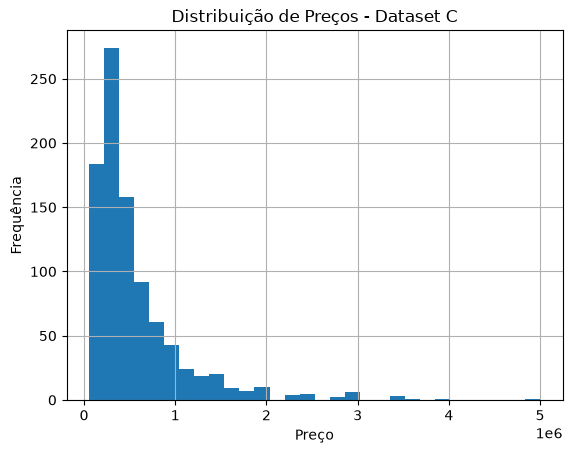

In [40]:
dataset_c['valor'].hist(bins=30)
plt.title("Distribuição de Preços - Dataset C")
plt.xlabel("Preço")
plt.ylabel("Frequência")
plt.show()

#### Histograma (com filtros)


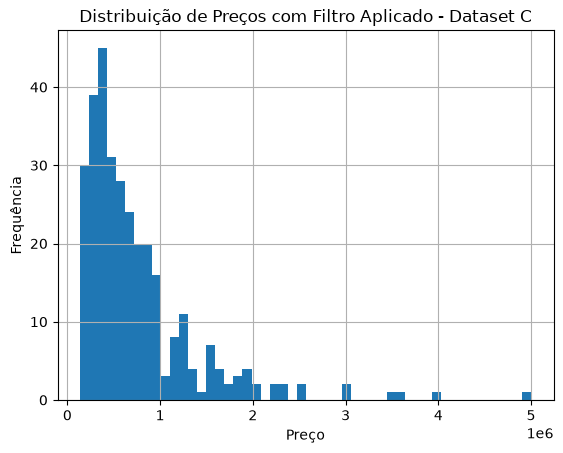

In [61]:
dataset_c_casas_padrao['valor'].hist(bins=50)
plt.title("Distribuição de Preços com Filtro Aplicado - Dataset C")
plt.xlabel("Preço")
plt.ylabel("Frequência")
plt.show()

## Tabela Comparativa


A tabela comparativa abaixo considerou somente os dados referentes à venda de casas, excluindo dados de outros tipos de imóveis ou de transações.

| Critério | Dataset A | Dataset B | Dataset C |
|---|---|---|---|
| 1. Quantidade de registros | 24.961 linhas | 1.085 linhas | 314 linhas |
| 2. Compatibilidade das colunas | Totalmente compatível | Totalmente compatível | Totalmente compatível |
| 3. Granularidade da localização | Possui coluna específica para Bairro | Necessário extrair dados de bairro da coluna de endereço | Possui coluna específica para Bairro |
| 4. Valores ausentes | Baixos; maior é 1.248 em `area_util` | Nenhum | Muitos em área útil |
| 5. Registros duplicados | 81 | 1 | 3 |
| 6. Qualidade dos dados | Boa, outliners pontuais, como 33 banheiros | Boa, mas necessário tratar dados de preço para avaliar | Baixa, Volume final pequeno de dados |
| 7. Facilidade de tratamento | Moderada | Moderada | Difícil por conta dos dados nulos |
| 8. Adequação ao modelo (Regressão Linear) | Exige logaritmo no preço para valores muito altos | | |
| **Decisão final** | | | |

Sobre a facilidade de tratamento em cada dataset

**Dataset A**

Moderada, pois exige: <br>
    (a) descartar colunas e linhas fora do escopo <br>
    (b) tratar nulos em `area_util` e `vagas_garagem` <br>
    (c) remover outliers extremos <br>
    (d) remover 81 duplicados <br>


**Dataset B**

Moderada, pois exige: <br>
    (a) extrair o `bairro` da columa `endereço_casa` (dado não vem isolado) <br>
    (b) converter `preco_casa` de texto (formato "R$ 760.00") para número <br>
    (c) remover 1 duplicado

**Dataset C**

Alta, pois exige: <br>
    (a) decidir entre descartar 247 linhas (78,7%) sem `area_util` — reduzindo o dataset a apenas 67 registros <br>
    (b) descartar colunas majoritariamente vazias ou não úteis para o projeto <br>
    (c) tratar outliers em `area_terreno` (máx. 56.580 m² vs. mediana de 300 m²), a confirmar extensão <br>
    (d) remover 3 duplicados <br>